In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.sample(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
5175,31,77,High,Medium,No,5,84,Medium,Yes,2,High,High,Public,Positive,5,No,NaN,Near,Male,73
1020,23,66,Medium,High,No,6,83,Medium,Yes,0,High,Medium,Public,Positive,2,No,High School,Near,Female,66
673,18,76,High,High,No,6,79,Medium,Yes,1,Medium,Medium,Private,Positive,2,No,Postgraduate,Far,Female,67
4861,15,78,Medium,High,No,4,57,High,Yes,2,Medium,High,Public,Negative,2,No,High School,Near,Female,65
4160,20,79,Medium,High,Yes,4,79,Low,Yes,0,Medium,High,Private,Neutral,4,No,High School,Moderate,Male,67


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

### Data Cleaning :-


In [4]:
# checking the shape of the dataset
df.shape

(6607, 20)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
# checking the null values across all columns
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
# making a copy of the dataset for cleaning & EDA
df1 = df.copy()
df1.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [8]:
# checking the number of null values in "Teacher_Quality" column
df1["Teacher_Quality"].isnull().sum()

np.int64(78)

In [9]:
df1["Teacher_Quality"].value_counts()

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

In [10]:
# filling null values in Teacher_Quality with mode because it is a categorical column
df1["Teacher_Quality"].fillna(df1["Teacher_Quality"].mode()[0], inplace=True)
df1["Teacher_Quality"].isnull().sum()

np.int64(0)

In [11]:
# checking the number of null values in "Parental_Education_Level" column
df1["Parental_Education_Level"].isnull().sum()

np.int64(90)

In [12]:
df1["Parental_Education_Level"].value_counts()

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

In [13]:
# filling null values in Parental_Education_Level with mode because it is a categorical column
df1["Parental_Education_Level"].fillna(df1["Parental_Education_Level"].mode()[0], inplace=True)
df1["Parental_Education_Level"].isnull().sum()

np.int64(0)

In [14]:
# checking the number of null values in "Distance_from_Home" column
df1["Distance_from_Home"].isnull().sum()

np.int64(67)

In [15]:
df1["Distance_from_Home"].value_counts()

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64

In [16]:
# filling null values in Distance_from_Home with mode because it is a categorical column
df1["Distance_from_Home"].fillna(df1["Distance_from_Home"].mode()[0], inplace=True)
df1["Distance_from_Home"].isnull().sum()

np.int64(0)

In [17]:
# verifying no null values remain in the dataset
df1.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

### EDA (Exploratory Data Analysis) :-


In [19]:
df1.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [20]:
df1.sample(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6260,28,69,Medium,Low,No,8,98,Medium,Yes,0,Medium,Medium,Public,Positive,5,No,High School,Near,Male,67
5588,27,60,Medium,High,No,8,68,High,Yes,1,Medium,Medium,Private,Negative,4,Yes,High School,Far,Female,63
4811,9,80,Medium,Low,Yes,4,52,Low,Yes,1,High,Medium,Public,Positive,2,No,Postgraduate,Near,Female,63
689,23,68,Low,Low,No,8,91,Medium,Yes,5,Low,Medium,Public,Negative,5,No,Postgraduate,Near,Female,66
4426,22,92,Medium,Low,No,5,72,Low,Yes,0,Medium,Medium,Private,Negative,4,No,College,Moderate,Male,67


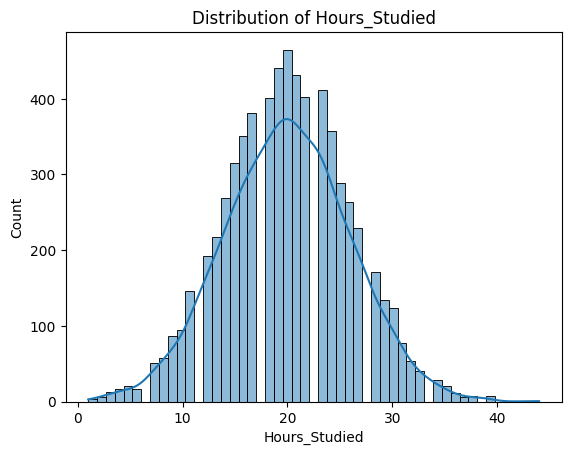

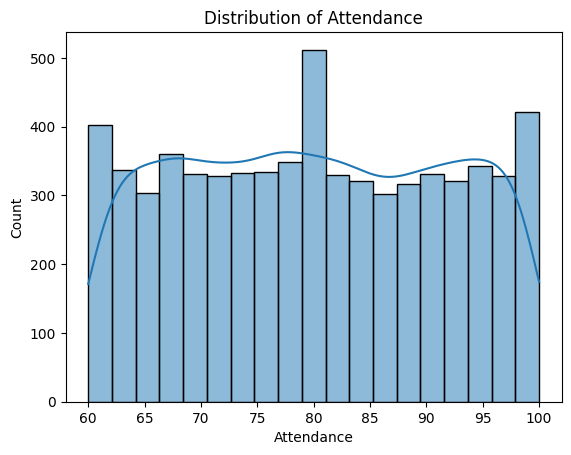

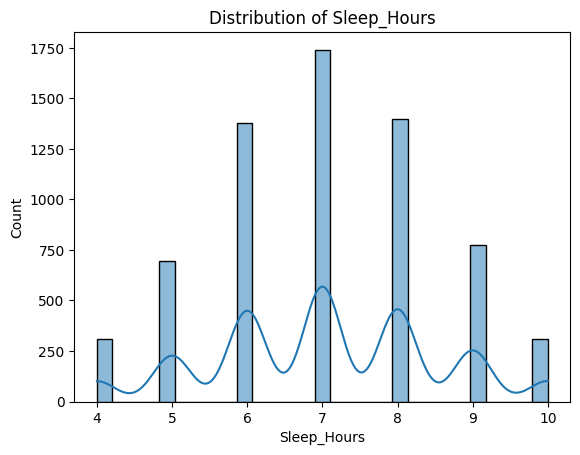

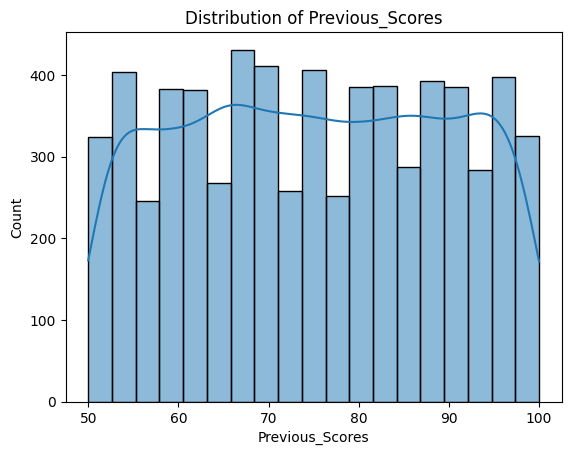

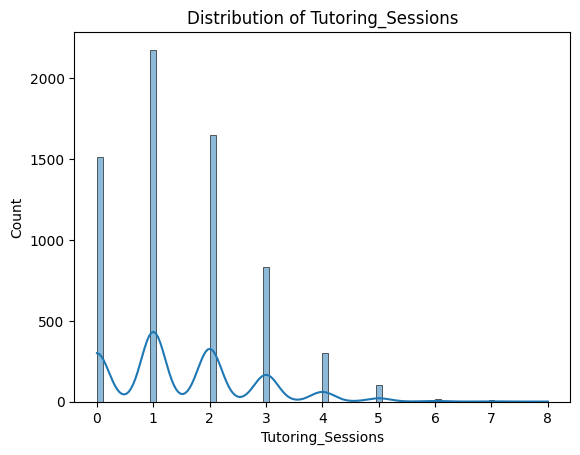

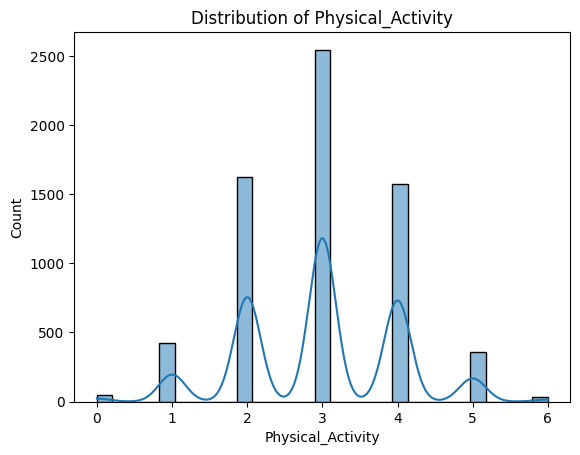

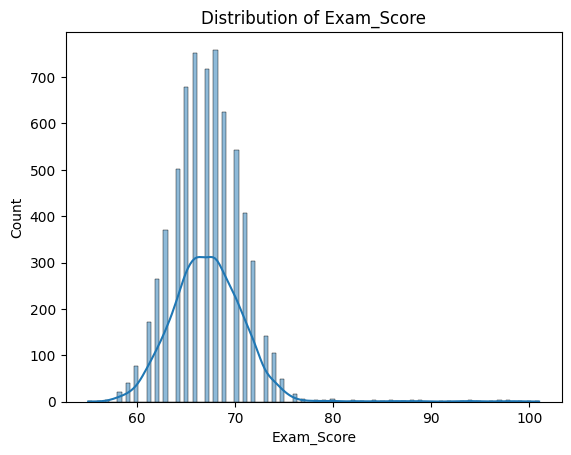

In [21]:
numCols = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
           "Tutoring_Sessions", "Physical_Activity", "Exam_Score"]

for col in numCols:
    sns.histplot(x=col, data=df1, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

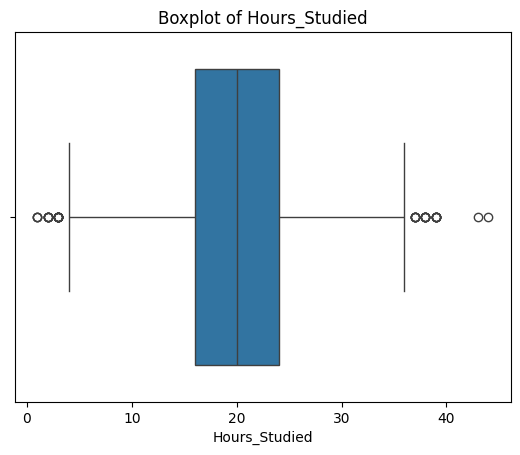

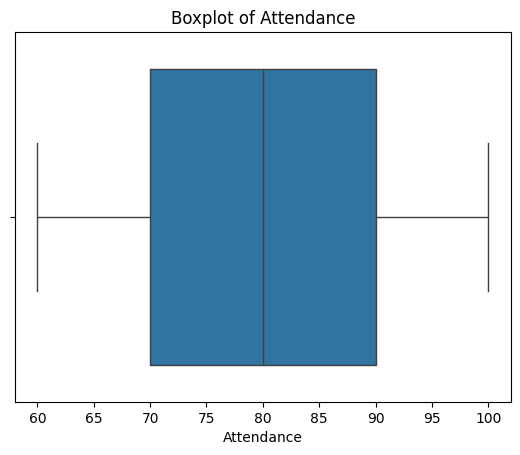

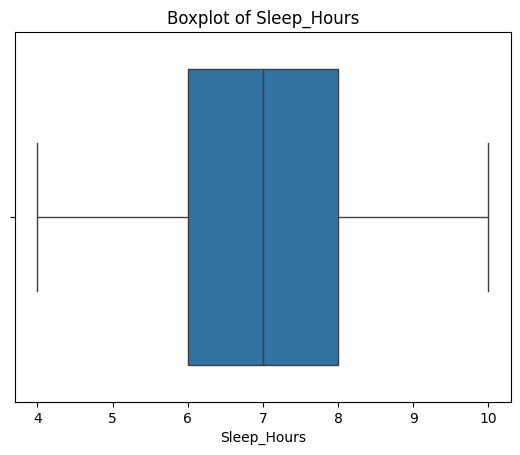

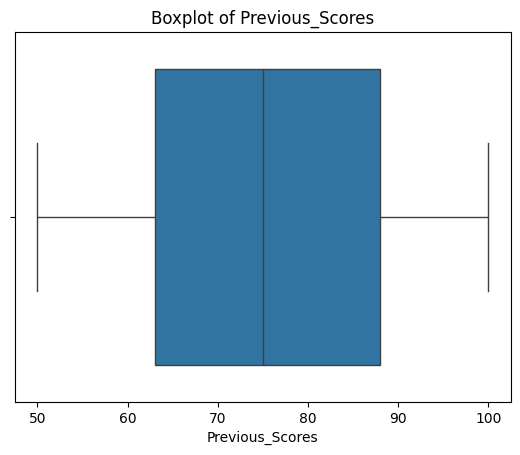

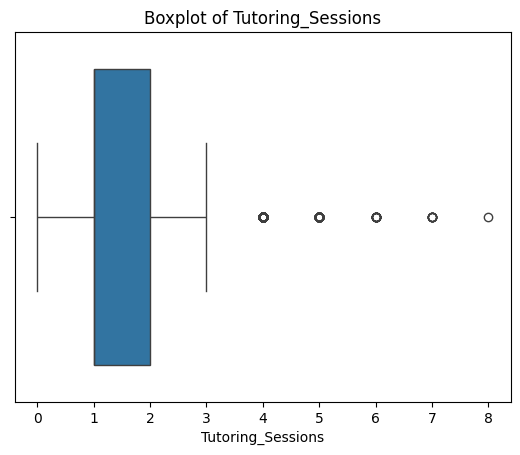

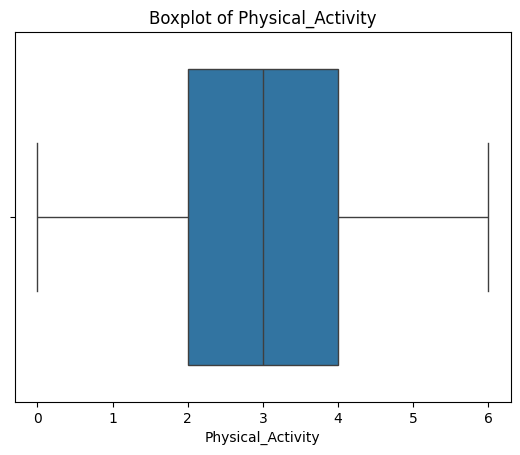

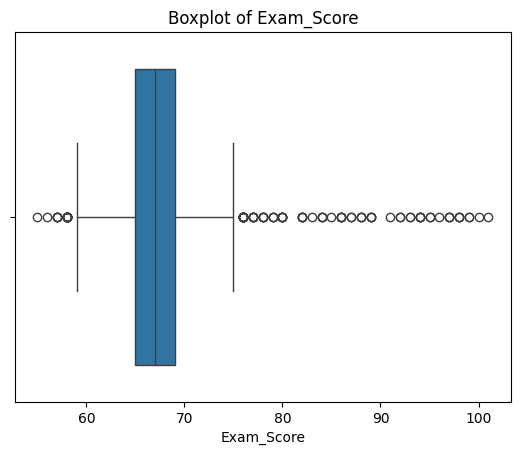

In [22]:
# visualizing the boxplot for numerical columns to check for outliers
for col in numCols:
    sns.boxplot(x=col, data=df1)
    plt.title(f"Boxplot of {col}")
    plt.show()

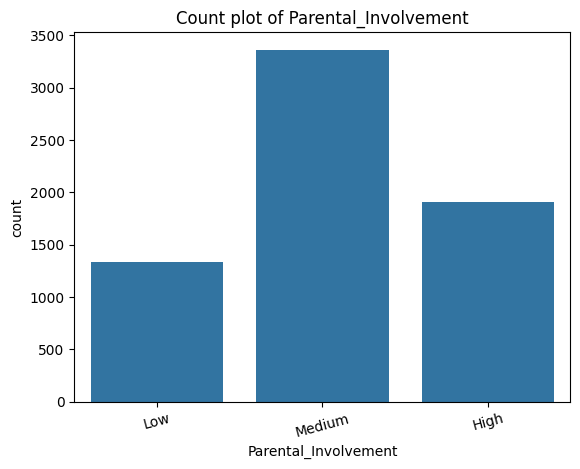

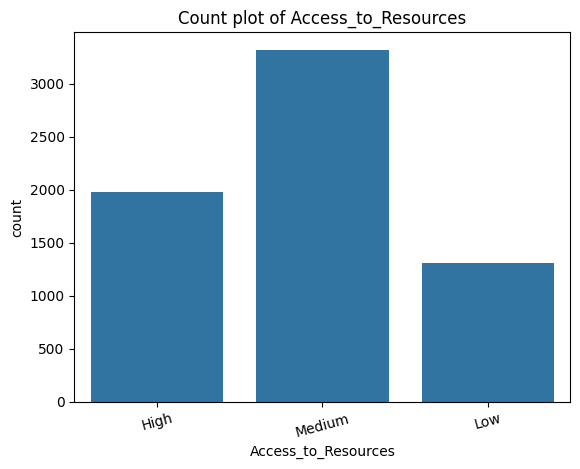

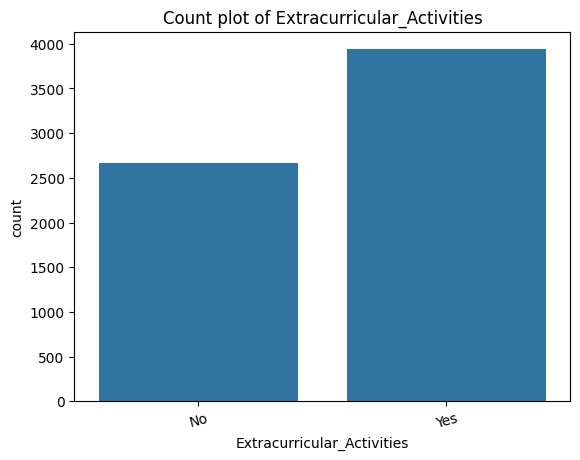

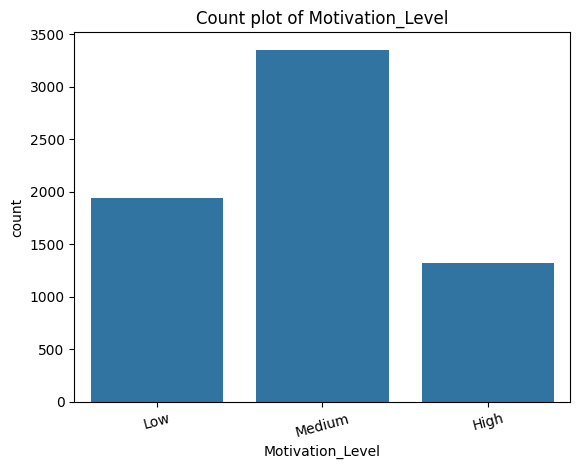

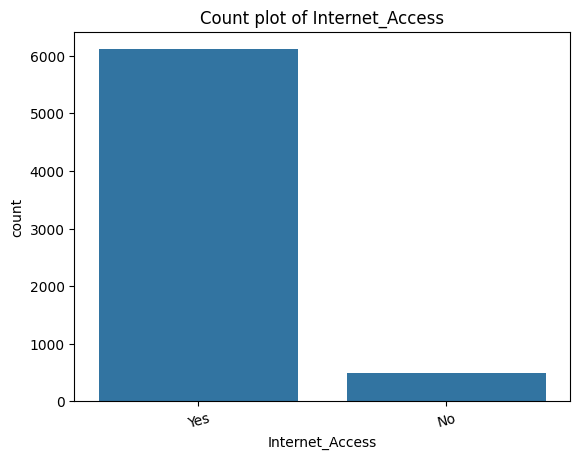

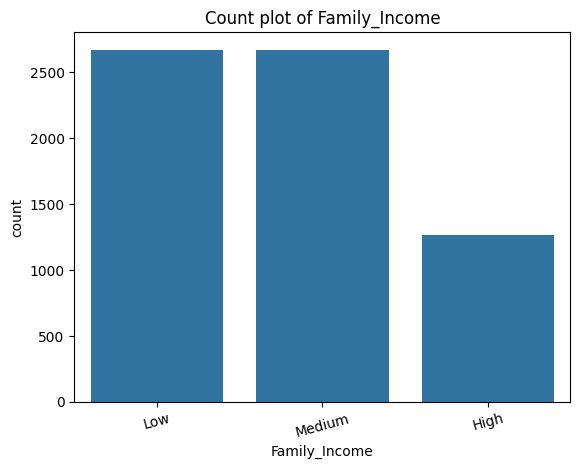

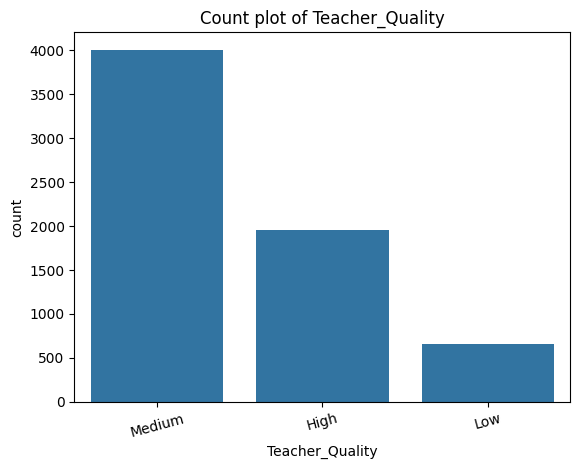

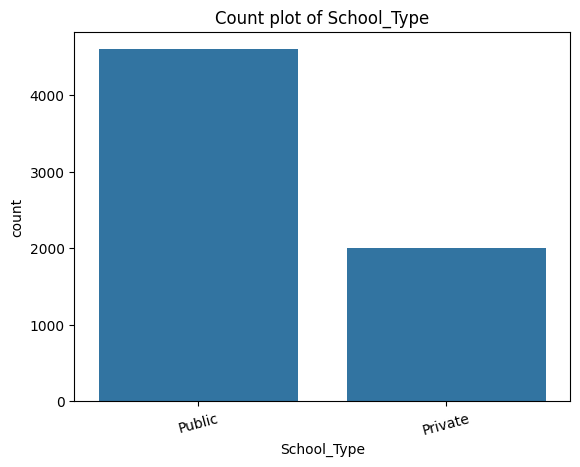

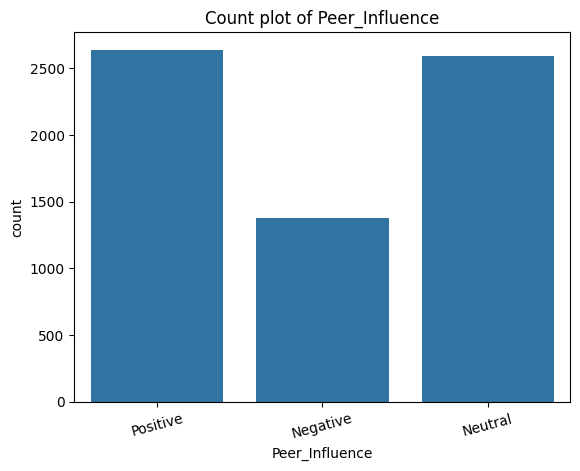

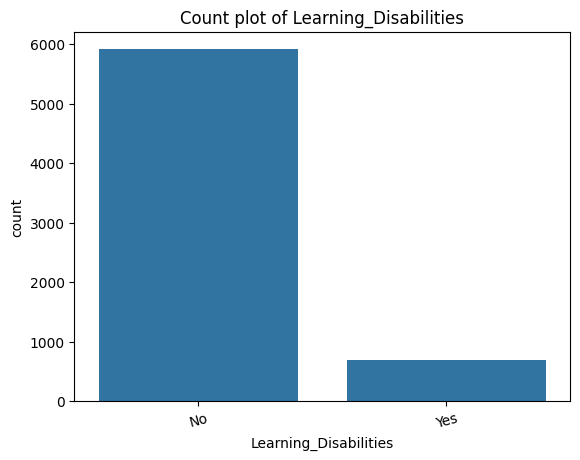

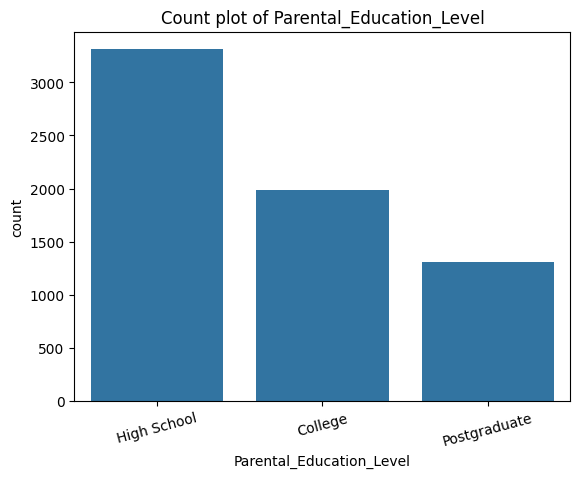

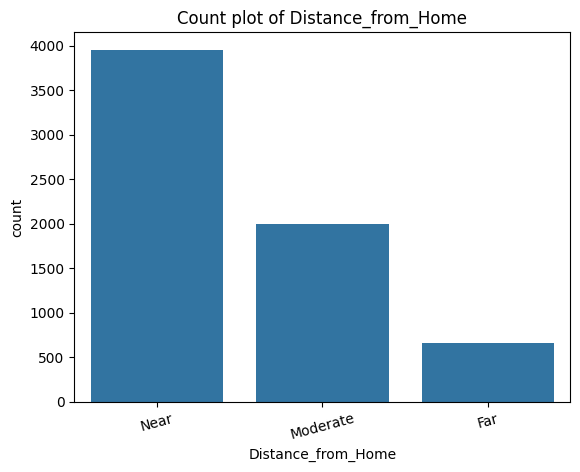

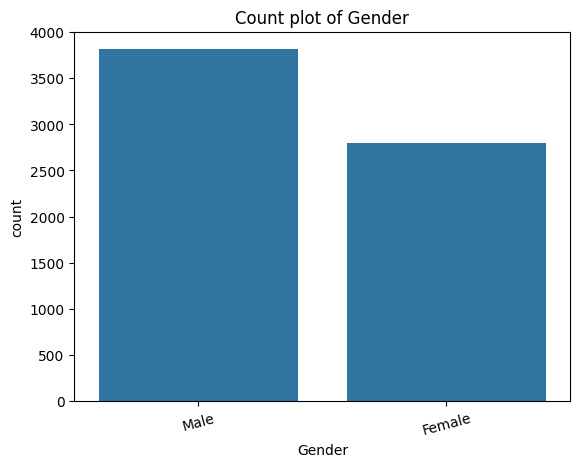

In [23]:
# visualizing all categorical columns using countplot
catCols = ["Parental_Involvement", "Access_to_Resources", "Extracurricular_Activities",
           "Motivation_Level", "Internet_Access", "Family_Income", "Teacher_Quality",
           "School_Type", "Peer_Influence", "Learning_Disabilities",
           "Parental_Education_Level", "Distance_from_Home", "Gender"]

for col in catCols:
    sns.countplot(x=col, data=df1)
    plt.title(f"Count plot of {col}")
    plt.xticks(rotation=15)
    plt.show()

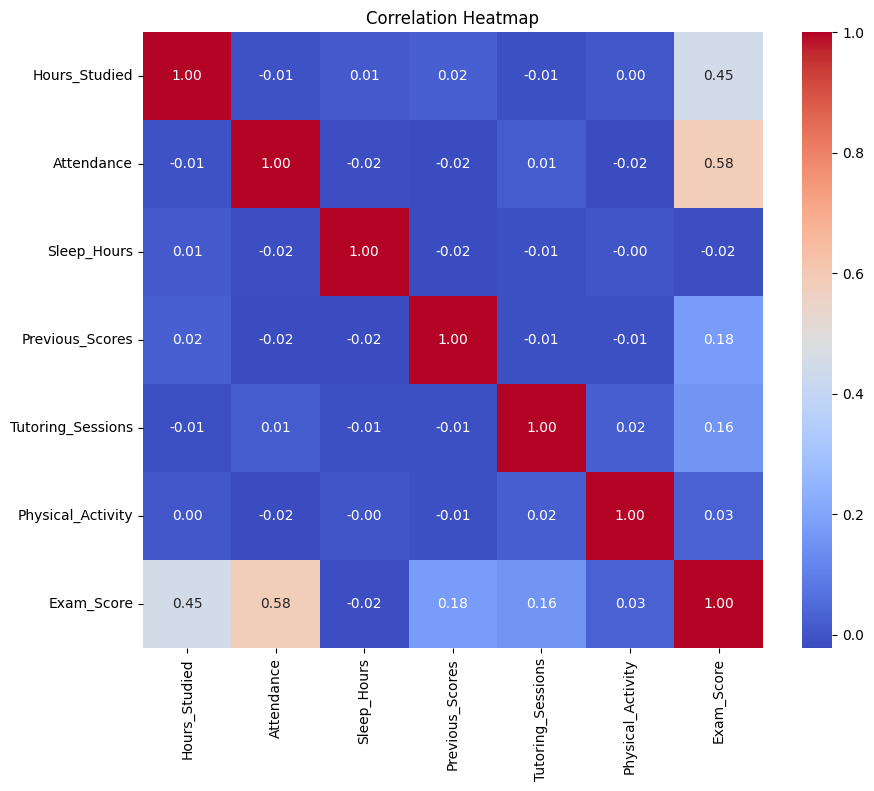

In [24]:
# visualizing the correlation between the numerical columns using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df1.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Label Encoding & One Hot Encoding :-


In [25]:
dfT = df1.copy()
dfT.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [26]:
# applying ordinal/label encoding to ordered categorical columns
from sklearn.preprocessing import LabelEncoder

ordinal_map = {
    "Parental_Involvement"    : {"Low": 0, "Medium": 1, "High": 2},
    "Access_to_Resources"     : {"Low": 0, "Medium": 1, "High": 2},
    "Motivation_Level"        : {"Low": 0, "Medium": 1, "High": 2},
    "Family_Income"           : {"Low": 0, "Medium": 1, "High": 2},
    "Teacher_Quality"         : {"Low": 0, "Medium": 1, "High": 2},
    "Parental_Education_Level": {"High School": 0, "College": 1, "Postgraduate": 2},
    "Distance_from_Home"      : {"Near": 0, "Moderate": 1, "Far": 2},
}

for col, mapping in ordinal_map.items():
    dfT[col] = dfT[col].map(mapping)

dfT.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0,2,No,7,73,0,Yes,0,0,1,Public,Positive,3,No,0,0,Male,67
1,19,64,0,1,No,8,59,0,Yes,2,1,1,Public,Negative,4,No,1,1,Female,61
2,24,98,1,1,Yes,7,91,1,Yes,2,1,1,Public,Neutral,4,No,2,0,Male,74
3,29,89,0,1,Yes,8,98,1,Yes,1,1,1,Public,Negative,4,No,0,1,Male,71
4,19,92,1,1,Yes,6,65,1,Yes,3,1,2,Public,Neutral,4,No,1,0,Female,70


In [27]:
# encoding binary categorical columns using Label Encoding
binary_cols = ["Extracurricular_Activities", "Internet_Access",
               "Learning_Disabilities", "Gender", "School_Type"]

le = LabelEncoder()
for col in binary_cols:
    dfT[col] = le.fit_transform(dfT[col])

dfT.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0,2,0,7,73,0,1,0,0,1,1,Positive,3,0,0,0,1,67
1,19,64,0,1,0,8,59,0,1,2,1,1,1,Negative,4,0,1,1,0,61
2,24,98,1,1,1,7,91,1,1,2,1,1,1,Neutral,4,0,2,0,1,74
3,29,89,0,1,1,8,98,1,1,1,1,1,1,Negative,4,0,0,1,1,71
4,19,92,1,1,1,6,65,1,1,3,1,2,1,Neutral,4,0,1,0,0,70


In [28]:
# applying One Hot Encoding to Peer_Influence column (nominal, no order)
dfT = pd.get_dummies(dfT, columns=["Peer_Influence"])
dfT.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive
0,23,84,0,2,0,7,73,0,1,0,...,1,3,0,0,0,1,67,False,False,True
1,19,64,0,1,0,8,59,0,1,2,...,1,4,0,1,1,0,61,True,False,False
2,24,98,1,1,1,7,91,1,1,2,...,1,4,0,2,0,1,74,False,True,False
3,29,89,0,1,1,8,98,1,1,1,...,1,4,0,0,1,1,71,True,False,False
4,19,92,1,1,1,6,65,1,1,3,...,1,4,0,1,0,0,70,False,True,False


In [29]:
dfT.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score', 'Peer_Influence_Negative', 'Peer_Influence_Neutral',
       'Peer_Influence_Positive'],
      dtype='object')

In [30]:
dfT = dfT.astype("int64")
dfT.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive
0,23,84,0,2,0,7,73,0,1,0,...,1,3,0,0,0,1,67,0,0,1
1,19,64,0,1,0,8,59,0,1,2,...,1,4,0,1,1,0,61,1,0,0
2,24,98,1,1,1,7,91,1,1,2,...,1,4,0,2,0,1,74,0,1,0
3,29,89,0,1,1,8,98,1,1,1,...,1,4,0,0,1,1,71,1,0,0
4,19,92,1,1,1,6,65,1,1,3,...,1,4,0,1,0,0,70,0,1,0


### MODEL Building :-


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = dfT.drop("Exam_Score", axis=1)
y = dfT["Exam_Score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set size : {X_train.shape}")
print(f"Testing  set size : {X_test.shape}")

Training set size : (5285, 21)
Testing  set size : (1322, 21)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# ----- 1. Linear Regression -----
model_LR = LinearRegression()
model_LR.fit(X_train_scaled, y_train)

# ----- 2. Decision Tree Regressor -----
model_DT = DecisionTreeRegressor(max_depth=8, random_state=42)
model_DT.fit(X_train, y_train)

# ----- 3. Random Forest Regressor -----
model_RF = RandomForestRegressor(n_estimators=200, random_state=42)
model_RF.fit(X_train, y_train)

# ----- 4. Gradient Boosting Regressor -----
model_GB = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
model_GB.fit(X_train, y_train)

# ----- 5. Support Vector Regressor -----
model_SVR = SVR(kernel="rbf", C=100, epsilon=0.1)
model_SVR.fit(X_train_scaled, y_train)

print("All models trained successfully!")

All models trained successfully!


### Model Evaluation :-


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred_LR  = model_LR.predict(X_test_scaled)
y_pred_DT  = model_DT.predict(X_test)
y_pred_RF  = model_RF.predict(X_test)
y_pred_GB  = model_GB.predict(X_test)
y_pred_SVR = model_SVR.predict(X_test_scaled)

models = {
    "Linear Regression"         : y_pred_LR,
    "Decision Tree Regressor"   : y_pred_DT,
    "Random Forest Regressor"   : y_pred_RF,
    "Gradient Boosting Regressor": y_pred_GB,
    "Support Vector Regressor"  : y_pred_SVR,
}

results = []
for name, y_pred in models.items():
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    results.append({"Model": name, "MAE": round(mae,4),
                    "MSE": round(mse,4), "RMSE": round(rmse,4), "R2 Score": round(r2,4)})
    print(f"==== {name} ====")
    print(f"  MAE      : {mae:.4f}")
    print(f"  MSE      : {mse:.4f}")
    print(f"  RMSE     : {rmse:.4f}")
    print(f"  R2 Score : {r2:.4f}")
    print()

results_df = pd.DataFrame(results)
results_df

==== Linear Regression ====
  MAE      : 0.4457
  MSE      : 3.2407
  RMSE     : 1.8002
  R2 Score : 0.7707

==== Decision Tree Regressor ====
  MAE      : 1.6167
  MSE      : 9.0700
  RMSE     : 3.0116
  R2 Score : 0.3583

==== Random Forest Regressor ====
  MAE      : 1.0658
  MSE      : 4.6451
  RMSE     : 2.1552
  R2 Score : 0.6714

==== Gradient Boosting Regressor ====
  MAE      : 0.7402
  MSE      : 3.8162
  RMSE     : 1.9535
  R2 Score : 0.7300

==== Support Vector Regressor ====
  MAE      : 0.7514
  MSE      : 3.9364
  RMSE     : 1.9840
  R2 Score : 0.7215



,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.4457,3.2407,1.8002,0.7707
1,Decision Tree Regressor,1.6167,9.0700,3.0116,0.3583
2,Random Forest Regressor,1.0658,4.6451,2.1552,0.6714
3,Gradient Boosting Regressor,0.7402,3.8162,1.9535,0.7300
4,Support Vector Regressor,0.7514,3.9364,1.9840,0.7215


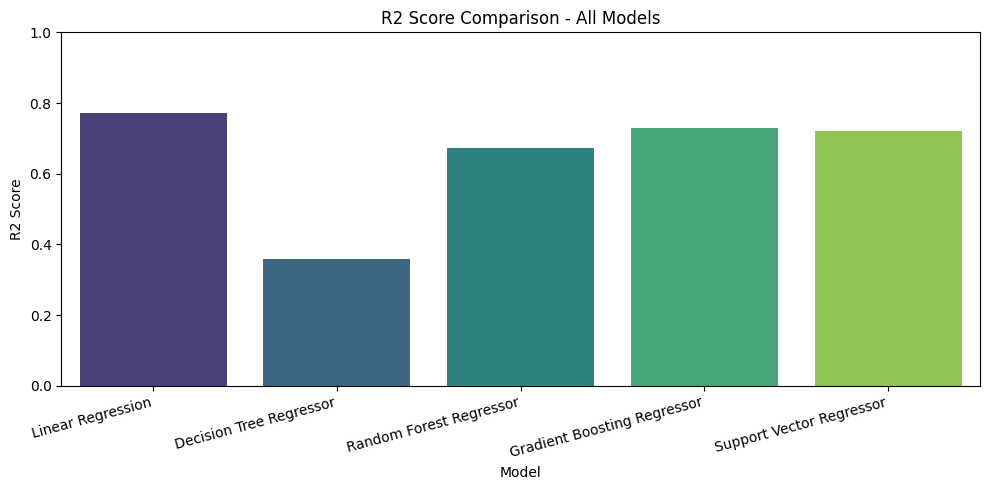

In [34]:
# visualizing the R2 Score comparison across all models
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="R2 Score", data=results_df, palette="viridis")
plt.title("R2 Score Comparison - All Models")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

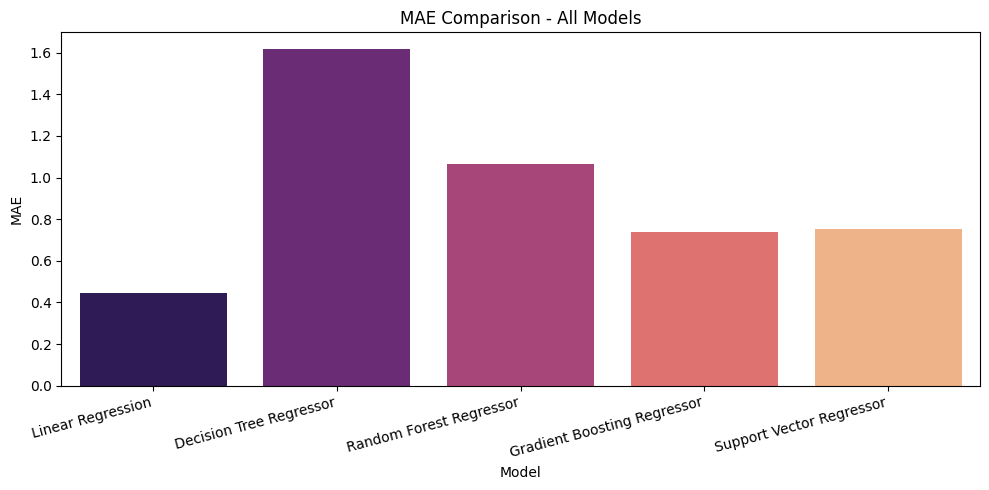

In [35]:
# visualizing the MAE comparison across all models
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="MAE", data=results_df, palette="magma")
plt.title("MAE Comparison - All Models")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [36]:
# identifying the best model based on R2 Score
best_model = results_df.loc[results_df["R2 Score"].idxmax(), "Model"]
best_r2    = results_df["R2 Score"].max()
print(f"Best Model  : {best_model}")
print(f"Best R2 Score: {best_r2}")

Best Model  : Linear Regression
Best R2 Score: 0.7707
